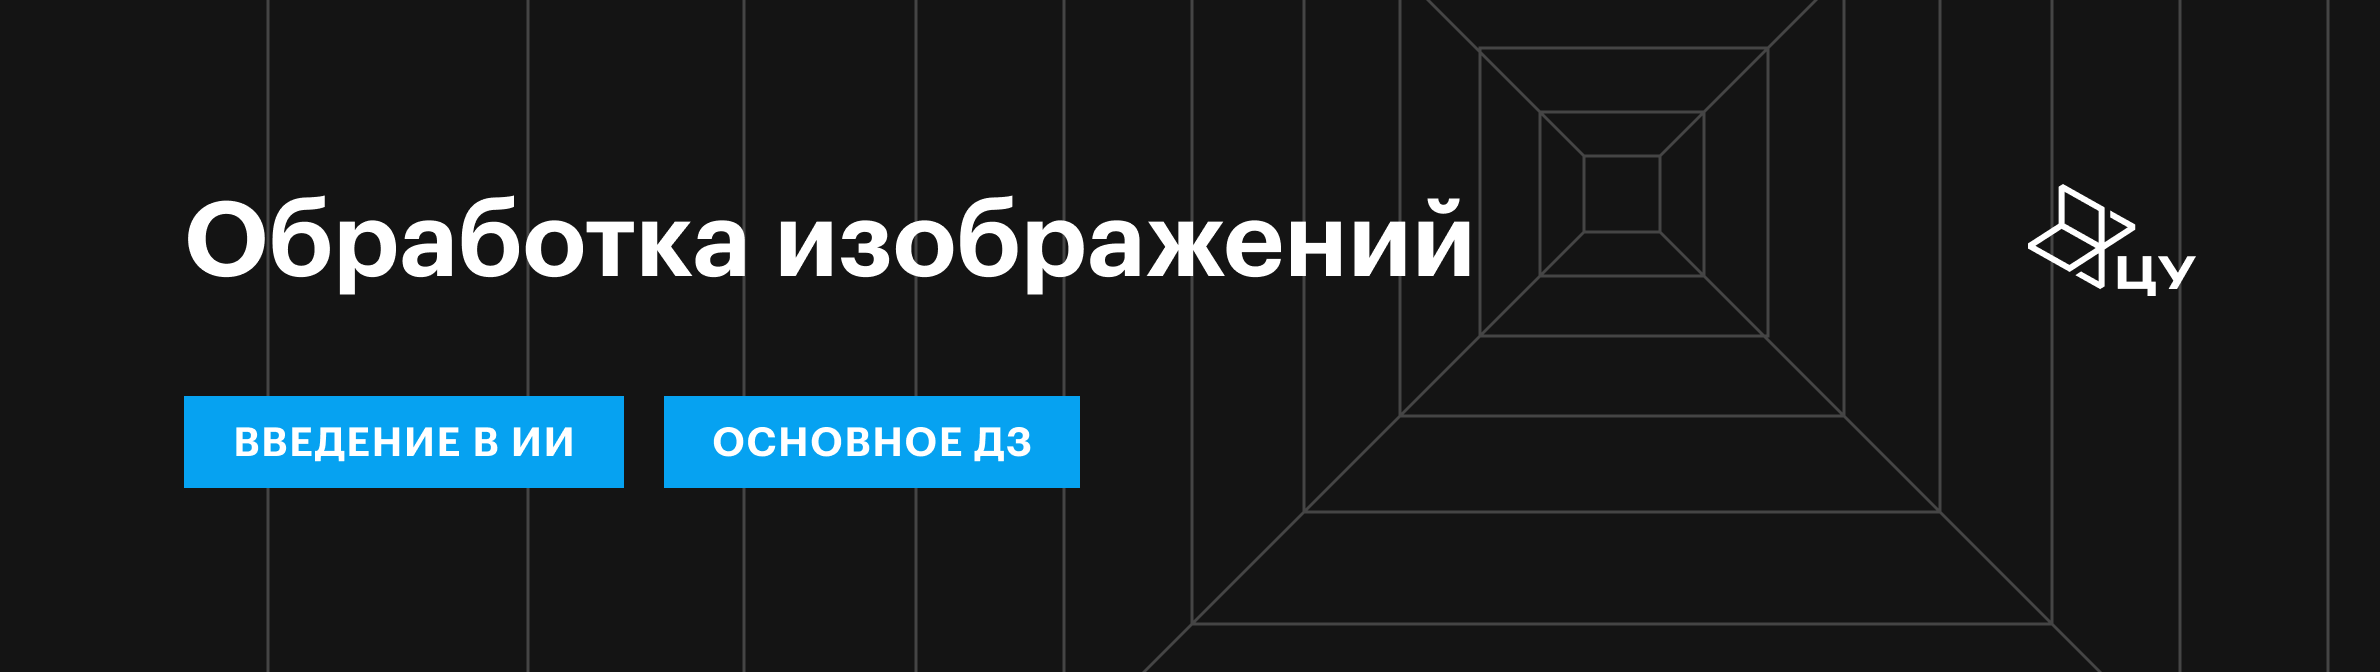

# Домашнее задание по теме «Обработка изображений»

Цель этого домашнего задания — разобраться, как изображение можно представить в виде признаков, какие ограничения у этого подхода и почему классические модели не всегда хорошо справляются с задачей.

Тебе нужно будет показать логику рассуждений: что хранит то или иное представление изображения, какая информация при этом теряется и как это влияет на качество модели.

> ### Правила домашнего задания
> 1. Нельзя удалять существующие ячейки кода.
> 2. Можно добавлять и дописывать свои ячейки.
> 3. Место, куда тебе нужно написать код, помечается комментарием.
> 4. Ответ без кода, который подтвердит твоё решение, не засчитывается. Исключение — задачи и вопросы, где код не требуется и нужно сделать вывод из известных данных.
> 5. Код должен быть работоспособным. У проверяющих должна быть возможность воспроизвести все полученные результаты.
> 6. Все графики подписывай так, чтобы можно было легко понять их суть. Избегай слишком мелкого или крупного текста, подписывай оси на одном языке.
> 7. В этом домашнем задании особенно важно пояснять, какие данные модель видит в признаках и какие закономерности может обнаружить.

## Описание задачи

Тебе нужно собрать прототип для распознавания изображений, используя простые признаки и классические модели. А также определить, в какой момент такой подход перестаёт работать.

## Подготовка данных

In [ ]:
# @title
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.datasets import load_sample_image, load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, confusion_matrix

np.random.seed(42)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["image.cmap"] = "gray"


Чтобы код запускался без скачиваний и дополнительной настройки, используй только встроенные данные из sklearn:

- `flower.jpg` — реальное цветное изображение для задач на яркость, преобразования и гистограммы;
- `digits` — маленький датасет изображений рукописных цифр размера `8 × 8` для задач на признаки и классификацию.

In [ ]:
# @title
def rgb_to_gray(img):
    """Перевод RGB-изображения в оттенки серого по стандартной взвешенной формуле."""
    gray = 0.299 * img[..., 0] + 0.587 * img[..., 1] + 0.114 * img[..., 2]
    return np.clip(gray, 0, 255).astype(np.uint8)

def hist_features(images, bins=16, value_range=(0, 1)):
    """Строит нормированные гистограммные признаки для набора изображений."""
    features = []
    for img in images:
        hist, _ = np.histogram(img, bins=bins, range=value_range)
        hist = hist.astype(np.float32)
        hist = hist / hist.sum()
        features.append(hist)
    return np.array(features)

def shift_right_batch(images, shift=1):
    """Сдвигает батч изображений вправо с заполнением нулями."""
    shifted = np.zeros_like(images)
    shifted[:, :, shift:] = images[:, :, :-shift]
    return shifted

def make_same_hist_patterns(size=32, seed=42):
    """Создаёт несколько разных бинарных изображений с одинаковой гистограммой."""
    left_right = np.zeros((size, size), dtype=np.uint8)
    left_right[:, size // 2:] = 255

    checkerboard = ((np.indices((size, size)).sum(axis=0) % 2) * 255).astype(np.uint8)

    shuffled = left_right.ravel().copy()
    rng = np.random.default_rng(seed)
    rng.shuffle(shuffled)
    shuffled = shuffled.reshape(size, size)

    return left_right, checkerboard, shuffled

def describe_gray_image(img):
    return {
        "mean": float(img.mean()),
        "std": float(img.std()),
        "min": int(img.min()),
        "max": int(img.max()),
    }

flower = load_sample_image("flower.jpg")
flower_gray = rgb_to_gray(flower)
digits = load_digits()

print("flower:", flower.shape, flower.dtype)
print("flower_gray:", flower_gray.shape, flower_gray.dtype)
print("digits.images:", digits.images.shape)

flower: (427, 640, 3) uint8
flower_gray: (427, 640) uint8
digits.images: (1797, 8, 8)


## Задание 1. Одинаковая гистограмма — разные изображения [2,5 балла]


На лекции мы обсуждали, что гистограмма показывает распределение яркостей, но не хранит информацию о том, где именно находятся пиксели. Проверь это на простом примере.

[0.5 баллa] Создай три бинарных изображения размера `32 × 32`, состоящих только из значений `0` и `255`:

- левая половина чёрная, правая — белая;
- шахматка;
- первое изображение со случайно перестановленными пикселями.

1. [0.5 баллa] Затем отобрази все три изображения.
2. [0.5 баллa] Для каждого построй гистограмму.
3. [0.5 баллa] Проверь, совпадает ли количество чёрных и белых пикселей.
4. [0.5 баллa] Объясни, почему изображения визуально очень разные, хотя их гистограммы одинаковые.

>**Подсказка.** У всех трёх изображений должно быть поровну чёрных и белых пикселей.

In [ ]:
pictures = {}

left_right_img = np.zeros([32, 32], dtype=np.uint8)
left_right_img[:, 16:] = 255
pictures["left_right"] = left_right_img

In [ ]:
checks_img = np.zeros([32, 32], dtype=np.uint8)
for i in range(32):
  checks_img[i, np.arange(i % 2, 32, 2)] = 255
pictures["checks"] = checks_img

In [ ]:
random_img = left_right_img.flatten()
np.random.shuffle(random_img)
random_img = random_img.reshape(32, 32)
pictures["random"] = random_img.reshape(32, 32)

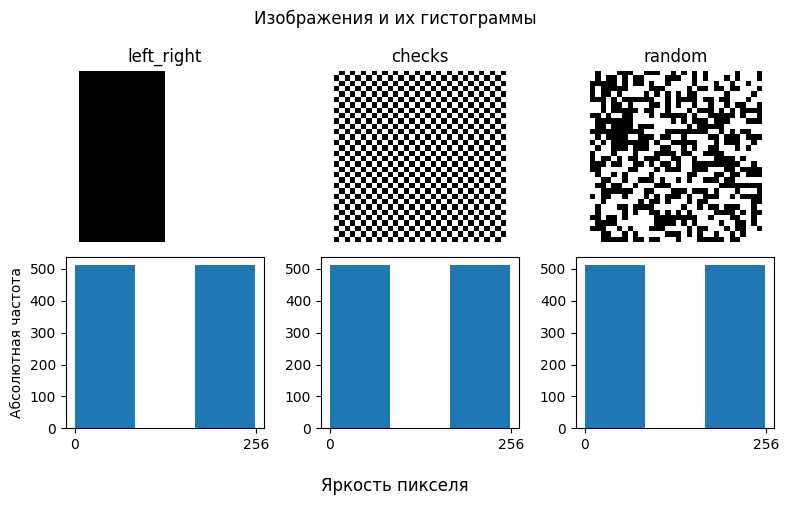

In [ ]:
hist_data = hist_features(pictures.values(), bins=2, value_range=(0, 255))

fig, axes = plt.subplots(2, len(pictures))
for i, name in enumerate(pictures):
  axes[0, i].imshow(pictures[name])
  axes[0, i].set_title(name)
  axes[0, i].axis("off")
  axes[0, i].set_frame_on(True)

  axes[1, i].hist(pictures[name].flatten(), bins=3)
  axes[1, i].set_xticks([0, 255])

axes[1, 0].set_ylabel("Абсолютная частота")
fig.suptitle("Изображения и их гистограммы")
fig.supxlabel("Яркость пикселя")

plt.tight_layout()
plt.show()

In [ ]:
print(hist_data)

[[0.5 0.5]
 [0.5 0.5]
 [0.5 0.5]]


Из графика и данных выше (доли черных и белых пикселей для каждого изображения), очевидно, что число пикселей черного и белого цветов совпадает.

Изображения получились разные, несмотря на идентичные гистограммы, поскольку гистограммы вовсе не учитывают местоположение пикселей того или иного цвета, лишь их количество.

## Задание 2. Как простые преобразования меняют глобальные признаки изображения [2,5 балла]


Теперь перейди к реальному изображению `flower.jpg`.

1. [0.4 баллa] Переведи изображение в оттенки серого.
2. [0.7 баллa] Построй четыре версии grayscale-изображения:
   - исходное;
   - горизонтальный флип;
   - более яркая версия (`+40` к яркости с обрезкой в диапазон `[0, 255]`);
   - версия с пониженным контрастом.
3. [0.7 баллa] Для каждой версии:
   - отобрази изображение;
   - построй гистограмму;
   - посчитай `mean`, `std`, `min`, `max`.
4. [0.7 баллa] Выясни, какие преобразования:
   - почти не меняют глобальное распределение яркостей,
   - заметно меняют распределение,
   - меняют структуру изображения без существенного изменения гистограммы.

>**Подсказка.** Пониженный контраст удобно делать как `new = mean + alpha * (img - mean)` при `alpha < 1`.

In [ ]:
flower_gray = rgb_to_gray(flower)

flowers = {}
flowers["origin"] = flower_gray
flowers["horizontal_flip"] = flower_gray[:, np.arange(flower_gray.shape[1] - 1, -1, -1)]
flowers["brighter_ver"] = np.clip(flower_gray + 40, 0, 255)

alpha = 0.5
mean = np.mean(flower_gray)
flowers["low_contrast"] = np.clip(mean + alpha * (flower_gray - mean), 0, 255).astype(np.uint8)

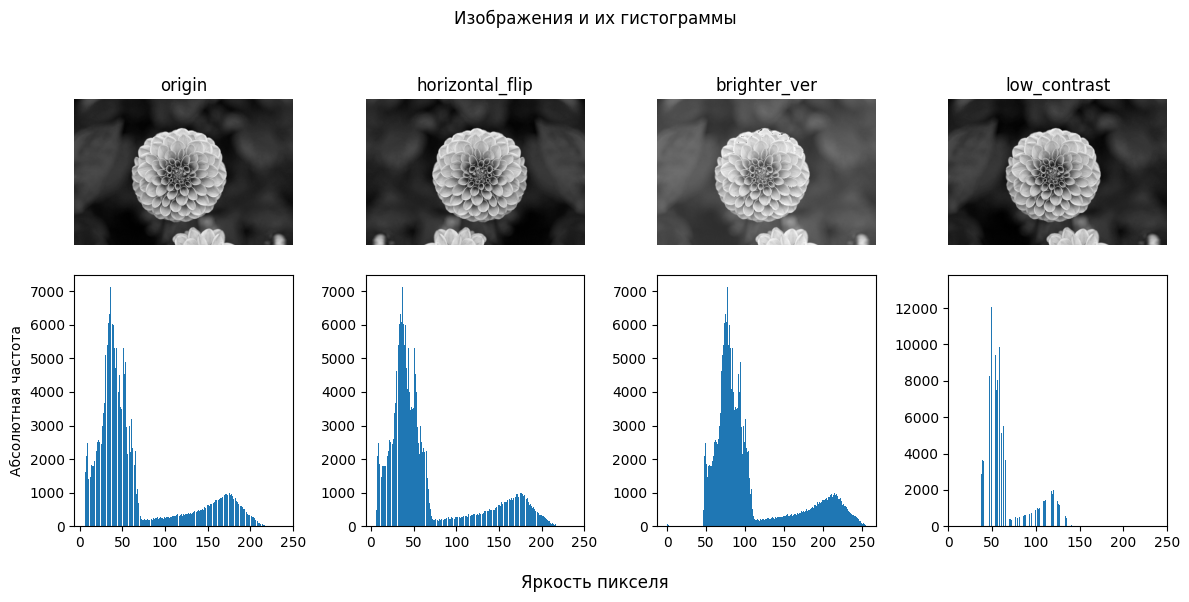

In [ ]:
fig, axes = plt.subplots(2, len(flowers), figsize=(12, 6))
for i, name in enumerate(flowers):
  axes[0, i].imshow(flowers[name])
  axes[0, i].set_title(name)
  axes[0, i].axis("off")
  axes[0, i].set_frame_on(True)

  axes[1, i].hist(flowers[name].flatten(), bins=256)
  axes[1, i].set_xticks(np.arange(0, 256, 50))

axes[1, 0].set_ylabel("Абсолютная частота")
fig.suptitle("Изображения и их гистограммы")
fig.supxlabel("Яркость пикселя")

plt.tight_layout()
plt.show()

In [ ]:
pd.DataFrame(map(describe_gray_image, flowers.values()), index=flowers)

,mean,std,min,max
origin,65.700344,52.774468,5,227
horizontal_flip,65.700344,52.774468,5,227
brighter_ver,105.553271,52.707140,0,255
low_contrast,65.100823,26.387424,35,146


Никак не изменяют:
- `horizontal_flip` - очевидно, т.к. пиксели остаются те же

Координально изменяют:
- `low_contrast` - столбики стали гораздо реже, стандартное отклонение почти в два раза ниже.

Меняют вид изображения, при этом не сильно меняя гистограмму:
- `brighter_ver` - несмотря на то, что среднее выросло, внещний вид остался тем же, однако визуальный эффект существенный.  

## Задание 3. Два способа описать изображение цифры [2,5 балла]

Теперь возьми датасет `digits` и оставь только цифры `3` и `8`.

Подготовь два разных представления одного и того же изображения.

1. `flatten`-представление — разверни изображение `8 × 8` в вектор длины `64`.
2. Гистограммное представление — построй по изображению нормированную гистограмму яркости из `16` бинов.

Выполни следующие шаги.

1. [0.2 баллa] Отбери только классы `3` и `8`.
2. [0.3 баллa] Нормируй значения пикселей в диапазон от `0` до `1`.
3. [0.2 баллa] Покажи по три примера каждого класса.
4. [0.8 баллa]Построй матрицы признаков `X_flat` и `X_hist`.
5. Выведи их размеры.
6. [0.7 баллa] Построй:
   - среднее изображение для каждого класса,
   - среднюю гистограмму для каждого класса.
7. [0.8 баллa] Сравни два представления:
   - какое хранит пространственную структуру;
   - какое компактнее;
   - какое потенциально устойчивее к небольшим перестановкам пикселей.

>**Важно.** Здесь нельзя просто написать «`flatten` лучше» или «`hist` хуже». Нужно объяснить, какую именно информацию хранит каждое представление.

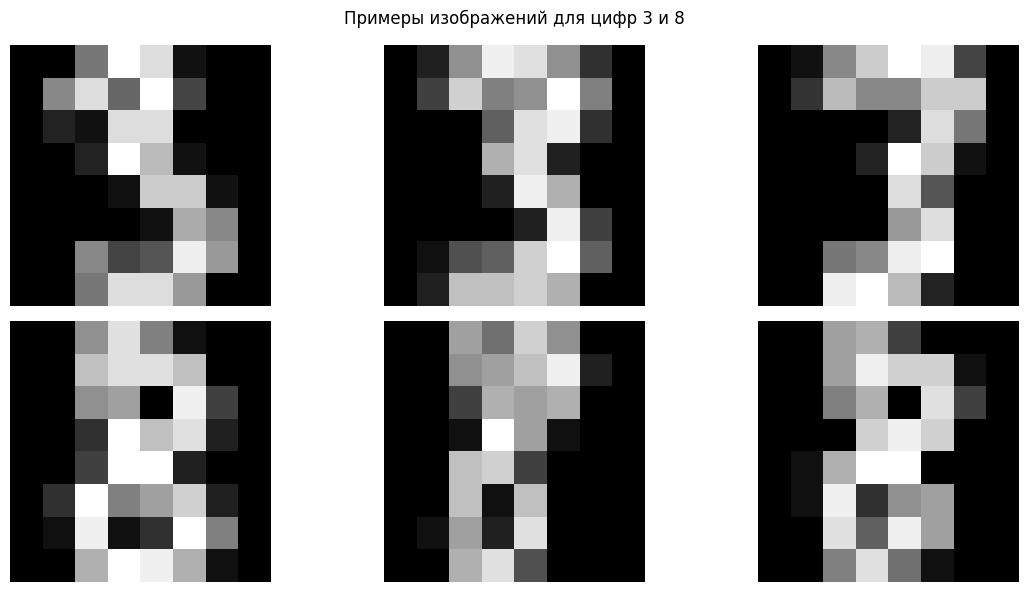

In [ ]:
filter_digits = {"3": {}, "8": {}}

for digit in filter_digits:
  filter_digits[digit]["img"] = digits["images"][digits["target"] == int(digit)]
  filter_digits[digit]["norm"] = filter_digits[digit]["img"] / 255

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for j, digit in enumerate(filter_digits):
  for i in range(3):
    axes[j][i].axis("off")
    axes[j][i].imshow(filter_digits[digit]["norm"][i])

fig.suptitle("Примеры изображений для цифр 3 и 8")
plt.tight_layout()
plt.show()

In [ ]:
for digit in filter_digits:
  filter_digits[digit]["flat"] = np.array([img.flatten() for img in filter_digits[digit]["norm"]])
  filter_digits[digit]["hist"] = np.array([np.histogram(img, bins=16)[0] for img in filter_digits[digit]["norm"]])

In [ ]:
print(filter_digits["3"]["flat"].shape)
print(filter_digits["3"]["hist"].shape)

(183, 64)
(183, 16)


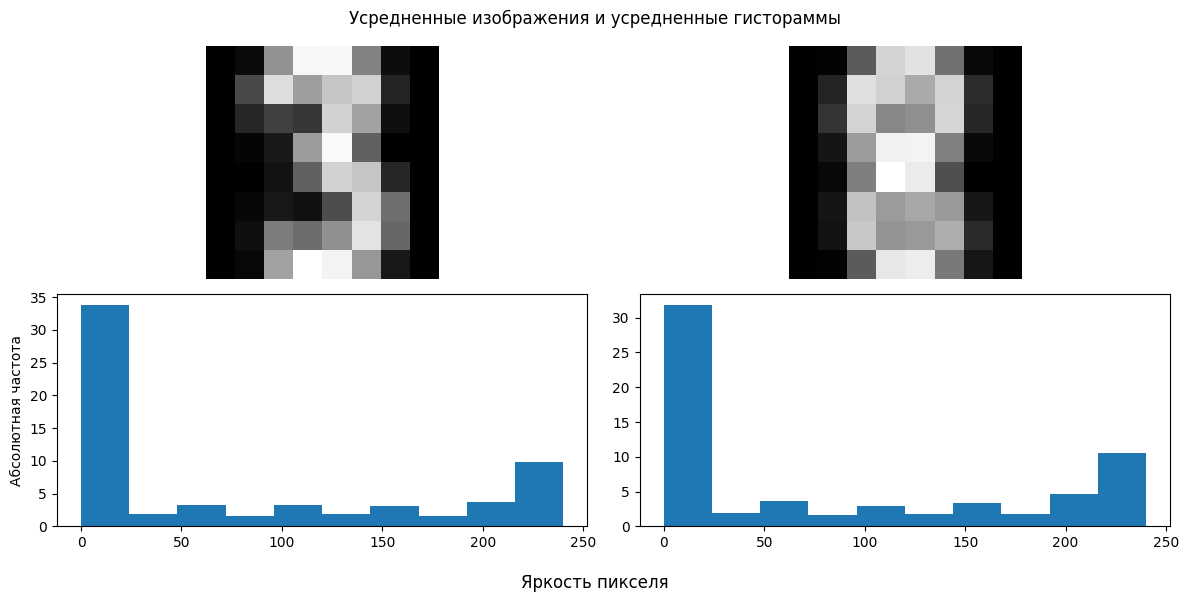

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

for i, digit in enumerate(filter_digits):
  axes[0][i].axis("off")
  axes[0][i].imshow(filter_digits[digit]["flat"].mean(axis=0).reshape(8, 8))
  axes[1][i].hist(np.arange(0, 256, 16), weights=filter_digits[digit]["hist"].mean(axis=0))

axes[1][0].set_ylabel("Абсолютная частота")
fig.supxlabel("Яркость пикселя")
fig.suptitle("Усредненные изображения и усредненные гистораммы")
plt.tight_layout()
plt.show()

Итак из выведенного выше имеем:
- `X_hist` компактнее, чем `X_flat` ($183\times 16$ vs $183\times 64$)
- `X_flat` хранит пространственную архитектру (было более подробно описано в №1-2)
- С точки зрения сохранения данных внутри структуры, как бы мы ни переставляли пиксели `X_hist` останется тем же, поэтому в данном вопросе он наиболее устойчив.

## Задание 4. Логистическая регрессия на `flatten` и чувствительность к сдвигу [2,5 балла]


Обучи логистическую регрессию на признаках `flatten`.

Выполни следующие шаги.

1. [0.1 баллa] Разбей данные на train и test (`stratify=y`, `random_state=42`).
2. [0.4 баллa] Обучи `LogisticRegression` на `X_flat`.
3. [0.2 баллa] Посчитай accuracy на обычном тесте.
4. [0.3 баллa] Создай новую версию тестовых изображений: сдвинь каждую цифру вправо на 1 пиксель с заполнением нулями.
5. [0.2 баллa] Снова посчитай accuracy — уже на сдвинутом тесте.
6. [0.3 баллa] Построй `confusion matrix`:
   - для обычного теста,
   - для сдвинутого теста.
7. [0.1 баллa] Покажи несколько примеров ошибок на сдвинутом тесте.
8. [0.4 баллa] Обучи ещё одну `LogisticRegression` на `X_hist` и сравни её качество на обычном и сдвинутом тесте.

[0.5 баллa] После этого ответь на вопросы.

- Почему модель на `flatten` может хорошо работать на исходных изображениях?
- Почему даже маленький сдвиг ухудшает качество?
- Почему модель на гистограммах слабее на обычном тесте, но может быть менее чувствительной к такому сдвигу?



### **Для `X_flat`**

In [ ]:
X = np.vstack((filter_digits["3"]["flat"], filter_digits["8"]["flat"]))
y = np.array(["3"] * len(filter_digits["3"]["flat"]) + ["8"] * len(filter_digits["8"]["flat"]))

In [ ]:
X_train, X_test, y_train, y_test_first = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y)

In [ ]:
model = LogisticRegression(max_iter=10_000)
model.fit(X_train, y_train)
y_pred_first = model.predict(X_test)

print(f"accuracy = {accuracy_score(y_test_first, y_pred_first) * 100:.2f}%")

accuracy = 97.22%


In [ ]:
new_digits = {"3": {}, "8": {}}

for digit in "3", "8":
  new_digits[digit]["img"] = shift_right_batch(filter_digits[digit]["img"])
  new_digits[digit]["norm"] = new_digits[digit]["img"] / 255
  new_digits[digit]["flat"] = np.array([img.flatten() for img in new_digits[digit]["norm"]])

X = np.vstack((new_digits["3"]["flat"], new_digits["8"]["flat"]))
y = np.array(["3"] * len(new_digits["3"]["flat"]) + ["8"] * len(new_digits["8"]["flat"]))

In [ ]:
_, X_test, _, y_test_second = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y)

y_pred_second = model.predict(X_test)
print(f"accuracy = {accuracy_score(y_test_second, y_pred_second) * 100:.2f}%")

accuracy = 63.89%


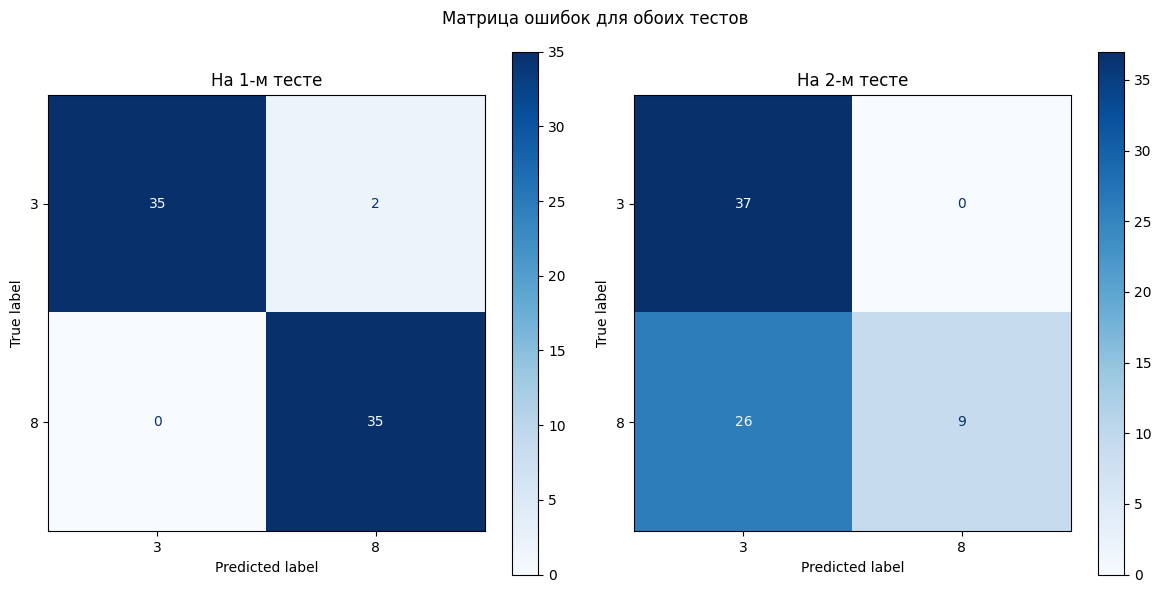

In [ ]:
results = [(y_test, y_pred_first), (y_test_second, y_pred_second)]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for i in range(2):
  disp = ConfusionMatrixDisplay(
      confusion_matrix=confusion_matrix(*results[i]),
      display_labels=["3", "8"]
  )
  disp.plot(ax=axes[i], cmap="Blues")
  axes[i].set_title(f"На {i + 1}-м тесте")

plt.suptitle("Матрица ошибок для обоих тестов")
plt.tight_layout()
plt.show()

### **Для `X_hist`**

In [ ]:
X = np.vstack((filter_digits["3"]["hist"], filter_digits["8"]["hist"]))
y = np.array(["3"] * len(filter_digits["3"]["hist"]) + ["8"] * len(filter_digits["8"]["hist"]))

In [ ]:
X_train, X_test, y_train, y_test_first = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y)

In [ ]:
model = LogisticRegression(max_iter=10_000)
model.fit(X_train, y_train)
y_pred_first = model.predict(X_test)

print(f"accuracy = {accuracy_score(y_test_first, y_pred_first) * 100:.2f}%")

accuracy = 62.50%


In [ ]:
new_digits = {"3": {}, "8": {}}

for digit in "3", "8":
  new_digits[digit]["img"] = shift_right_batch(filter_digits[digit]["img"])
  new_digits[digit]["norm"] = new_digits[digit]["img"] / 255
  new_digits[digit]["hist"] = np.array([np.histogram(img, bins=16)[0] for img in new_digits[digit]["norm"]])

X = np.vstack((new_digits["3"]["hist"], new_digits["8"]["hist"]))
y = np.array(["3"] * len(new_digits["3"]["hist"]) + ["8"] * len(new_digits["8"]["hist"]))

In [ ]:
_, X_test, _, y_test_second = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y)

y_pred_second = model.predict(X_test)
print(f"accuracy = {accuracy_score(y_test_second, y_pred_second) * 100:.2f}%")

accuracy = 63.89%


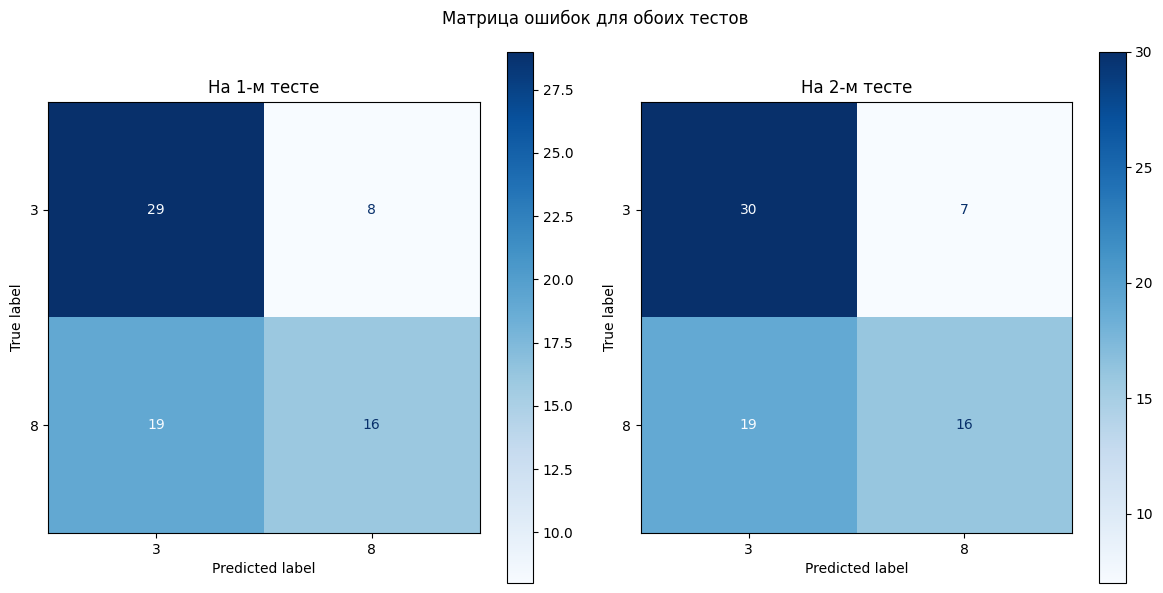

In [ ]:
results = [(y_test, y_pred_first), (y_test_second, y_pred_second)]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for i in range(2):
  disp = ConfusionMatrixDisplay(
      confusion_matrix=confusion_matrix(*results[i]),
      display_labels=["3", "8"]
  )
  disp.plot(ax=axes[i], cmap="Blues")
  axes[i].set_title(f"На {i + 1}-м тесте")

plt.suptitle("Матрица ошибок для обоих тестов")
plt.tight_layout()
plt.show()

- Модель `flatten` так или иначе "выучивает" представление цифр 3 и 8 в пространстве векоторов размерности 64, и поскольку указанные цифры, очевидно, имеют эталонный образ, т.е. при наложении большинство совпадет, модель может это приблизить линейной функцией.
- Модель запоминает не образ, а лишь конкретные положения пикселей в рамках данной (16X16) сетки, поэтому сдвиг имеет такое сильное влияние.
- Вообще говоря то, что модель работает одинаково плохо ($\approx \ln 2\%$, т.е. почти наугад), нельзя говорить о том, что она "стабильнее". Тем не менее это обуславливается тем, что данная модель никак не зависит от геометрического положения пикселей, а изменение якростей на границах почти всегда не дает существенных изменений, т.к. там они все черного цвета.